In [1]:
import pandas as pd
import numpy as np
import tenseal as ts
import time
import pickle
import os
import matplotlib.pyplot as plt

# Load PCA Compressed Embeddings

In [2]:
compressed_df = pd.read_csv(
    "../Outputs/Notebook_05/normalized_features.csv"
)

print("Shape:", compressed_df.shape)

compressed_df.head()

Shape: (7172, 128)


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.504552,0.128399,-0.008315,0.047153,-0.043397,-0.103234,-0.085967,0.010331,0.100802,-0.196828,...,0.015335,-0.027714,0.003905,-0.018692,0.002632,0.083104,-0.059229,-0.006409,-0.028560,0.029820
1,-0.293427,0.116267,0.129997,0.055071,0.192078,-0.134855,-0.014686,0.097043,0.096254,-0.243248,...,-0.053667,0.009824,-0.015993,-0.046944,0.029626,0.030832,-0.031089,-0.054888,-0.007307,-0.019793
2,-0.721961,-0.260858,0.017269,0.072744,0.144101,-0.126142,0.140952,0.054586,-0.048229,-0.096785,...,-0.025253,-0.006061,-0.011157,-0.008558,0.010828,-0.012625,0.016732,-0.028763,0.023174,-0.005484
3,-0.074147,0.318850,-0.159332,0.213617,0.305519,-0.092689,0.132614,-0.330092,0.057322,0.176601,...,0.046560,-0.026896,-0.036573,-0.114693,-0.020586,0.023030,0.025454,0.043049,-0.032155,0.029073
4,0.006369,0.275045,0.011515,0.370384,0.150590,-0.140550,0.168051,-0.291906,-0.108388,0.213981,...,-0.015956,-0.031725,-0.006668,-0.007204,0.019924,0.038178,-0.042487,0.029743,0.006211,0.020600


In [3]:
print(compressed_df.columns[:10])

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='str')


# Analyze Embedding Dataset

In [4]:
print(compressed_df.info())

compressed_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7172 entries, 0 to 7171
Columns: 128 entries, 0 to 127
dtypes: float64(128)
memory usage: 7.0 MB
None


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
count,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,...,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000
mean,-0.013090,0.024334,-0.008510,-0.001598,0.009883,0.000874,-0.003953,-0.003881,0.003115,-0.000835,...,0.000114,0.000094,-0.000096,-0.000119,-0.000008,0.000124,-0.000131,-0.000030,0.000048,-0.000092
std,0.456628,0.290832,0.246903,0.220906,0.204715,0.190645,0.184511,0.178221,0.156224,0.151384,...,0.029888,0.029924,0.029476,0.029548,0.029229,0.029106,0.028882,0.028589,0.028543,0.028597
min,-0.878542,-0.779865,-0.725016,-0.625172,-0.653723,-0.697447,-0.627270,-0.598458,-0.608617,-0.546315,...,-0.111662,-0.139511,-0.115406,-0.137065,-0.116357,-0.120200,-0.116393,-0.103285,-0.102282,-0.137565
25%,-0.429954,-0.156810,-0.170785,-0.158697,-0.125961,-0.125176,-0.130544,-0.121396,-0.103121,-0.100996,...,-0.019281,-0.019800,-0.019928,-0.019548,-0.019497,-0.019470,-0.019070,-0.019303,-0.018962,-0.018949
50%,0.066728,0.061341,0.011842,-0.004488,0.015691,0.006216,-0.004169,0.000544,0.005698,-0.002106,...,0.000055,-0.000405,-0.000271,-0.000003,-0.000423,0.000392,0.000109,0.000050,0.000008,0.000162
75%,0.383649,0.246070,0.171240,0.153916,0.152890,0.134117,0.121396,0.116033,0.106894,0.099343,...,0.019319,0.020247,0.019536,0.019386,0.019282,0.019585,0.018976,0.019256,0.019005,0.019118
max,0.806535,0.736905,0.657397,0.704297,0.653701,0.569904,0.591564,0.622789,0.625531,0.547883,...,0.111206,0.114205,0.117137,0.117091,0.130552,0.117608,0.141438,0.097596,0.131232,0.120555


# Create CKKS Encryption Context

In [5]:
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60,40,40,60]
)

context.global_scale = 2**40

context.generate_galois_keys()

context.generate_relin_keys()

print("CKKS Context Created Successfully")

CKKS Context Created Successfully


# Display CKKS Parameters

In [6]:
print("Global Scale:", context.global_scale)

Global Scale: 1099511627776.0


# Extract Image IDs and Feature Vectors

In [7]:
features = compressed_df.values

print(
    "Feature Shape:",
    features.shape
)

Feature Shape: (7172, 128)


# Visualize Sample Embedding

In [8]:
print(features[0][:20])

[ 0.50455246  0.12839932 -0.00831504  0.04715252 -0.04339745 -0.10323394
 -0.08596724  0.01033132  0.10080187 -0.19682759  0.43832629 -0.0437058
  0.19385998 -0.01407862 -0.04146907 -0.08311801  0.03549991 -0.18776332
  0.02849756 -0.07553085]


# Encrypt Single Sample Embedding

In [9]:
sample_encrypted = ts.ckks_vector(
    context,
    features[0].tolist()
)

print("Sample Encryption Successful")

Sample Encryption Successful


# Analyze Encrypted Template Size

In [10]:
serialized_sample = sample_encrypted.serialize()

print(
    "Encrypted Template Size:",
    len(serialized_sample),
    "bytes"
)

Encrypted Template Size: 333996 bytes


# Encrypt Complete Embedding Dataset

In [11]:
encrypted_embeddings = []

encryption_times = []

for row in features:

    start_time = time.time()

    encrypted_vector = ts.ckks_vector(
        context,
        row.tolist()
    )

    end_time = time.time()

    encrypted_embeddings.append(
        encrypted_vector.serialize()
    )

    encryption_times.append(
        end_time - start_time
    )

print("Dataset Encryption Completed")

Dataset Encryption Completed


# Save Encrypted Templates

In [12]:
os.makedirs(
    "../Outputs/Notebook_06",
    exist_ok=True
)

with open(
    "../Outputs/Notebook_06/encrypted_embeddings.pkl",
    "wb"
) as f:

    pickle.dump(
        encrypted_embeddings,
        f
    )

print("Encrypted Templates Saved")

Encrypted Templates Saved


# Generate Encryption Statistics

In [13]:
stats_df = pd.DataFrame({

    "Embedding_ID": range(
        len(encryption_times)
    ),

    "Encryption_Time": encryption_times

})

stats_df.to_csv(
    "../Outputs/Notebook_06/encryption_statistics.csv",
    index=False
)

stats_df.head()

,Embedding_ID,Encryption_Time
0,0,0.004836
1,1,0.016369
2,2,0.008845
3,3,0.005402
4,4,0.007321


# Compute Average Encryption Time

In [14]:
avg_time = np.mean(encryption_times)

print(
    "Average Encryption Time:",
    avg_time,
    "seconds"
)

Average Encryption Time: 0.00765344575338369 seconds


# Memory Usage Analysis

In [15]:
memory_usage = []

for item in encrypted_embeddings:

    memory_usage.append(
        len(item)
    )

memory_df = pd.DataFrame({

    "Embedding_ID": range(
        len(memory_usage)
    ),

    "Memory_Bytes": memory_usage

})

memory_df.to_csv(
    "../Outputs/Notebook_06/memory_usage_analysis.csv",
    index=False
)

print(
    "Average Memory Usage:",
    np.mean(memory_usage),
    "bytes"
)

Average Memory Usage: 334290.40686001116 bytes


# Encryption Time Distribution

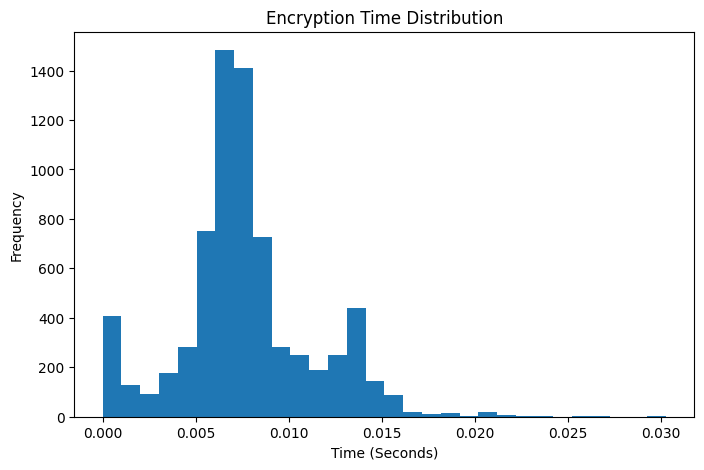

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    encryption_times,
    bins=30
)

plt.title("Encryption Time Distribution")

plt.xlabel("Time (Seconds)")

plt.ylabel("Frequency")

plt.savefig(
    "../Outputs/Notebook_06/encryption_time_distribution.png"
)

plt.show()

# Memory Usage Distribution

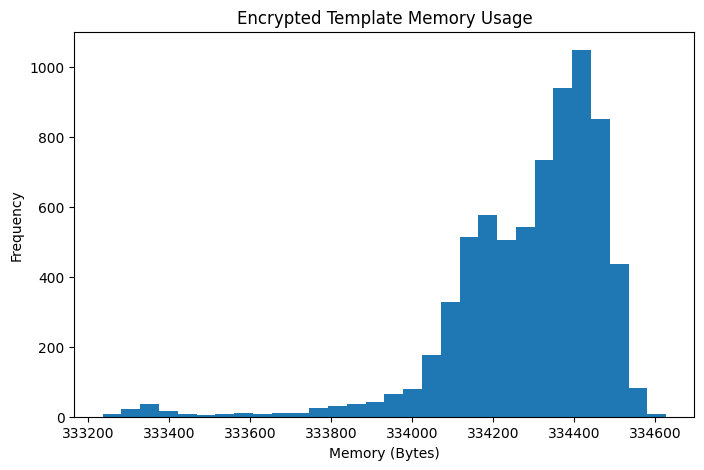

In [17]:
plt.figure(figsize=(8,5))

plt.hist(
    memory_usage,
    bins=30
)

plt.title("Encrypted Template Memory Usage")

plt.xlabel("Memory (Bytes)")

plt.ylabel("Frequency")

plt.savefig(
    "../Outputs/Notebook_06/memory_usage_distribution.png"
)

plt.show()

# Encryption Statistics Summary

In [18]:
summary_df = pd.DataFrame({
    "Metric":[
        "Average Encryption Time",
        "Average Memory Usage"
    ],
    "Value":[
        np.mean(encryption_times),
        np.mean(memory_usage)
    ]
})

summary_df.to_csv(
    "../Outputs/Notebook_06/encryption_summary.csv",
    index=False
)

summary_df

,Metric,Value
0,Average Encryption Time,0.007653
1,Average Memory Usage,334290.406860


In [19]:
import pickle

with open(
    "../Outputs/Notebook_06/encrypted_embeddings.pkl",
    "rb"
) as f:

    encrypted_embeddings = pickle.load(f)

print(type(encrypted_embeddings))
print(len(encrypted_embeddings))

<class 'list'>
7172


# Save CKKS Context

In [20]:
context_bytes = context.serialize(
    save_secret_key=True
)

with open(
    "../Outputs/Notebook_06/context.pkl",
    "wb"
) as f:

    pickle.dump(
        context_bytes,
        f
    )

print("CKKS Context Saved")

CKKS Context Saved


In [21]:
import pickle

with open(
    "../Outputs/Notebook_06/context.pkl",
    "rb"
) as f:

    context_bytes = pickle.load(f)

print(type(context_bytes))

<class 'bytes'>


In [22]:
import os

size_mb = os.path.getsize(
    "../Outputs/Notebook_06/encrypted_embeddings.pkl"
) / (1024*1024)

print(
    f"{size_mb:.2f} MB"
)

2286.50 MB


In [23]:
print(features.shape)

print(type(encrypted_embeddings[0]))

(7172, 128)
<class 'bytes'>
